# Mutual Fund Exploratory Data Analysis

Explore the cleaned Day 2 datasets with interactive Plotly and static Seaborn/Matplotlib charts. Run top to bottom. Every figure is exported to `reports/charts/` as a PNG. Figures use source coverage and do not fabricate missing months or observations.

**Coverage notes:** NAV history runs from January 2022 through May 2026 (not December 2026); category inflows are available only from April 2024 through March 2025. AUM is reported at nine source dates, so yearly comparisons use each fund house's latest reported observation in that calendar year. Portfolio holdings are one snapshot dated 2025-12-31. Daily NAV has holiday/weekend forward-filled dates as described in the data dictionary.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data' / 'processed'
CHART_DIR = ROOT / 'reports' / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams['figure.dpi'] = 120
NAV = pd.read_csv(DATA_DIR / '02_nav_history.csv', parse_dates=['date'])
FUND = pd.read_csv(DATA_DIR / '01_fund_master.csv', parse_dates=['launch_date'])
AUM = pd.read_csv(DATA_DIR / '03_aum_by_fund_house.csv', parse_dates=['date'])
SIP = pd.read_csv(DATA_DIR / '04_monthly_sip_inflows.csv', parse_dates=['month'])
CATEGORY = pd.read_csv(DATA_DIR / '05_category_inflows.csv', parse_dates=['month'])
FOLIO = pd.read_csv(DATA_DIR / '06_industry_folio_count.csv', parse_dates=['month'])
PERFORMANCE = pd.read_csv(DATA_DIR / '07_scheme_performance.csv')
TRANSACTIONS = pd.read_csv(DATA_DIR / '08_investor_transactions.csv', parse_dates=['transaction_date'])
HOLDINGS = pd.read_csv(DATA_DIR / '09_portfolio_holdings.csv', parse_dates=['portfolio_date'])
BENCHMARKS = pd.read_csv(DATA_DIR / '10_benchmark_indices.csv', parse_dates=['date'])

assert FUND.amfi_code.nunique() == 40
assert NAV.amfi_code.nunique() == 40
assert SIP.month.min() == pd.Timestamp('2022-01-01') and SIP.month.max() == pd.Timestamp('2025-12-01')
assert int(SIP.loc[SIP.sip_inflow_crore.idxmax(), 'sip_inflow_crore']) == 31002
assert set(TRANSACTIONS.transaction_type.unique()) == {'SIP', 'Lumpsum', 'Redemption'}
assert set(TRANSACTIONS.kyc_status.unique()) <= {'Verified', 'Pending'}
print(f"Loaded {len(FUND)} funds; NAV {NAV.date.min():%Y-%m-%d} to {NAV.date.max():%Y-%m-%d}; "
      f"category inflows {CATEGORY.month.min():%Y-%m} to {CATEGORY.month.max():%Y-%m}; "
      f"{len(TRANSACTIONS):,} investor transactions.")
print(f"PNG destination: {CHART_DIR}")

CHARTS = []
def save_plotly(fig, name, title):
    fig.update_layout(title=title, template='plotly_white', height=650, margin=dict(l=60, r=40, t=90, b=60))
    path = CHART_DIR / f'{name}.png'
    try:
        fig.write_image(str(path), width=1400, height=850, scale=1)
    except (ValueError, ImportError) as exc:
        warnings.warn(f"PNG export unavailable for {name}: {exc}. Install/enable Plotly's Kaleido backend.")
    CHARTS.append((name, path))
    return fig

def save_seaborn(fig, name):
    path = CHART_DIR / f'{name}.png'
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    CHARTS.append((name, path))
    return fig

def finish_plotly(fig):
    display(fig)
    return fig

def finish_seaborn(fig):
    display(fig)
    plt.close(fig)


Loaded 40 funds; NAV 2022-01-03 to 2026-05-29; category inflows 2024-04 to 2025-03; 32,778 investor transactions.
PNG destination: c:\Users\nihar\OneDrive\Desktop\Mutual Funds Analysis\reports\charts


## 1. NAV trends: daily levels and indexed performance

The raw NAV scale differs substantially across schemes, so the indexed chart rebases each scheme to 100 at its first observed date for cross-scheme trend comparison. Dashed/shaded regions mark 2023 and the 2024 correction window; they are visual periods, not claims of a causal event.

In [2]:
nav_plot = NAV.merge(FUND[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
nav_plot['scheme_name'] = nav_plot['scheme_name'].fillna(nav_plot.amfi_code.astype(str))
fig = px.line(nav_plot, x='date', y='nav', color='scheme_name', render_mode='webgl',
              title='Daily NAV — all 40 schemes (actual coverage: 2022–May 2026)',
              labels={'date':'Date','nav':'NAV (₹)','scheme_name':'Scheme'},
              hover_data={'amfi_code':True,'date':'%Y-%m-%d','nav':':.4f'})
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='#2ca02c', opacity=.08,
              line_width=0, annotation_text='2023 period', annotation_position='top left')
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='#d62728', opacity=.07,
              line_width=0, annotation_text='2024 correction window', annotation_position='top left')
fig.update_layout(legend=dict(orientation='h', y=-.22, title='Scheme'), hovermode='x unified')
finish_plotly(save_plotly(fig, '01_nav_daily_all_schemes', 'Daily NAV — all 40 funds'));

nav_indexed = nav_plot.sort_values('date').copy()
nav_indexed['indexed_nav'] = nav_indexed['nav'] / nav_indexed.groupby('amfi_code')['nav'].transform('first') * 100
fig = px.line(nav_indexed, x='date', y='indexed_nav', color='scheme_name', render_mode='webgl',
              labels={'date':'Date','indexed_nav':'NAV index (first observation = 100)','scheme_name':'Scheme'})
fig.add_hline(y=100, line_dash='dot', line_color='gray')
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='#2ca02c', opacity=.08, line_width=0)
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='#d62728', opacity=.07, line_width=0)
fig.update_layout(legend=dict(orientation='h', y=-.22), hovermode='x unified')
finish_plotly(save_plotly(fig, '02_nav_indexed_40_schemes', 'Indexed daily NAV — comparable fund growth'));

annual_nav = nav_plot.assign(year=nav_plot.date.dt.year).sort_values('date').groupby(['amfi_code','scheme_name','year'], as_index=False).agg(first_nav=('nav','first'),last_nav=('nav','last'))
annual_nav['calendar_year_return_pct'] = (annual_nav.last_nav / annual_nav.first_nav - 1) * 100
fig = px.box(annual_nav.query('year >= 2022 and year <= 2025'), x='year', y='calendar_year_return_pct', points='all',
             labels={'calendar_year_return_pct':'Within-year NAV change (%)','year':'Calendar year'})
finish_plotly(save_plotly(fig, '03_nav_annual_distribution', 'Distribution of within-year NAV changes by scheme'))

## 2. Fund-house AUM

For each year, the latest available snapshot is selected per fund house. Values are shown in ₹ lakh crore (₹ crore divided by 100,000); the SBI callout uses the observed 2025-12 value.

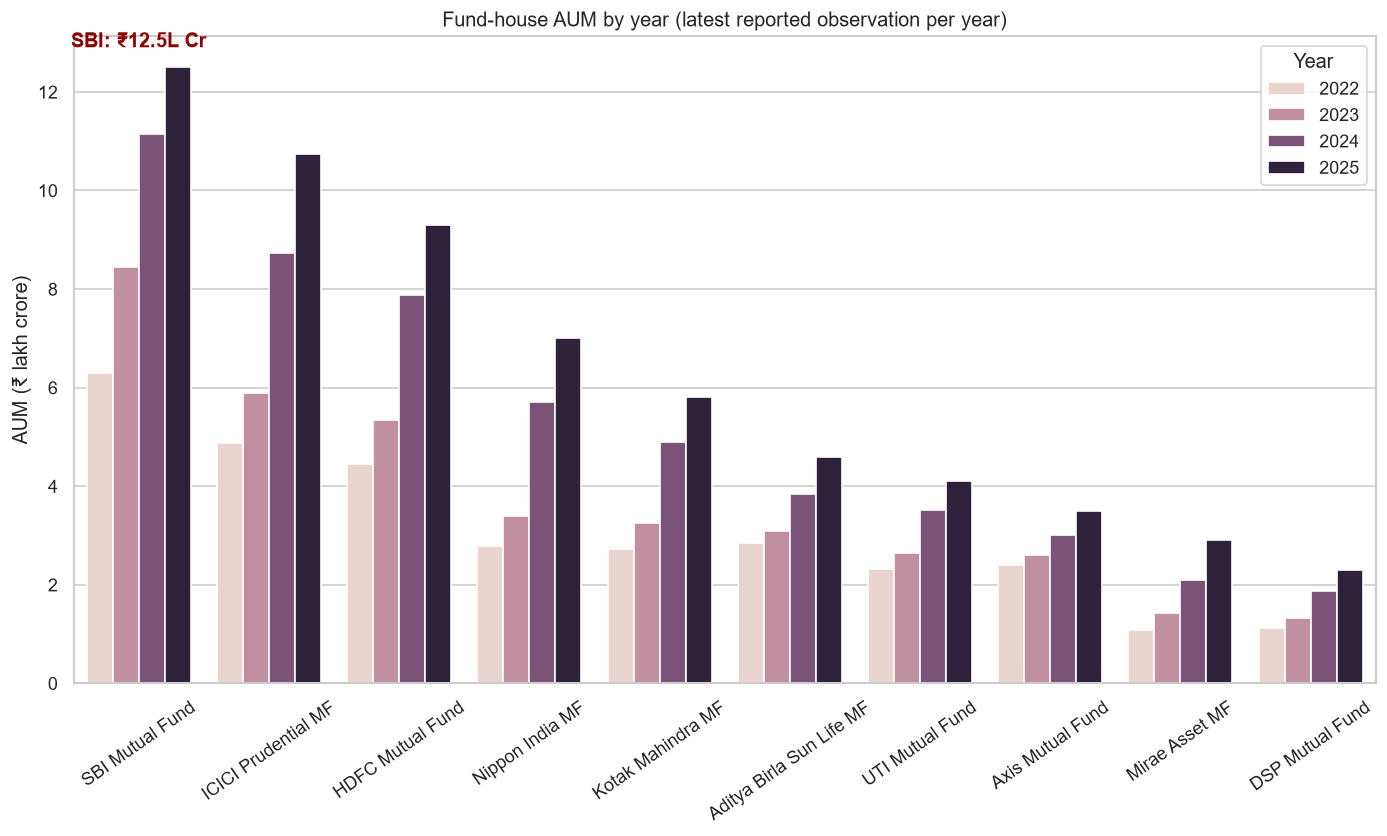

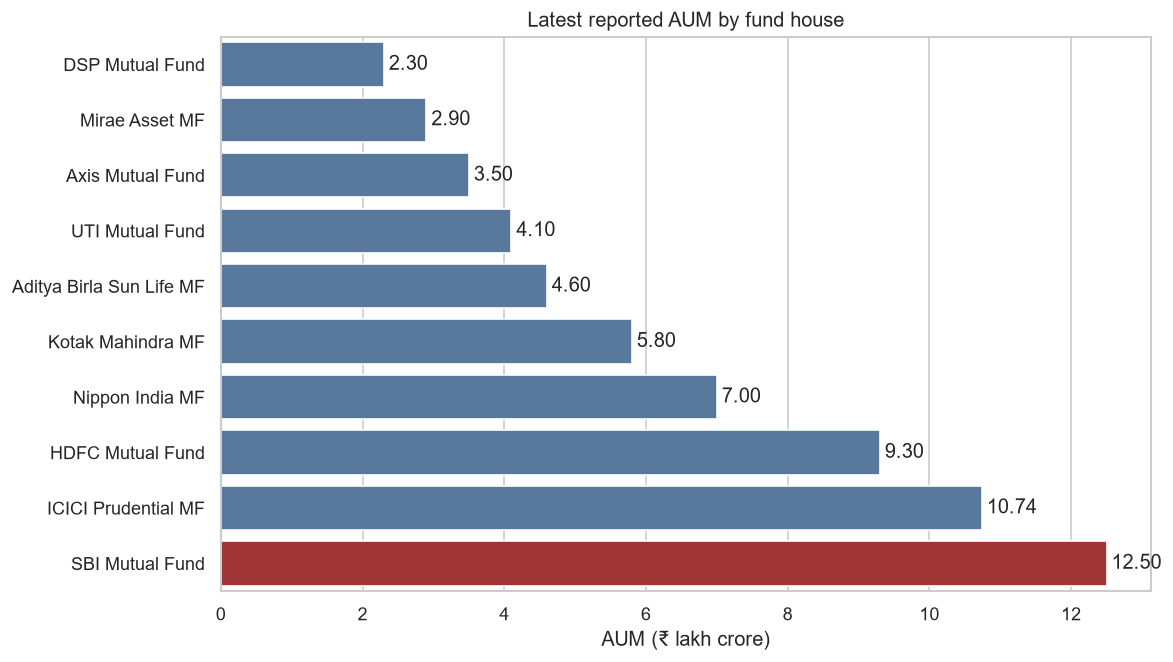

In [3]:
aum_yearly = AUM.assign(year=AUM.date.dt.year).query('year >= 2022 and year <= 2025').sort_values('date').groupby(['year','fund_house'], as_index=False).tail(1).copy()
aum_yearly['aum_lakh_crore_actual'] = aum_yearly.aum_crore / 100000
years = sorted(aum_yearly.year.unique())
fig, ax = plt.subplots(figsize=(14,7))
sns.barplot(data=aum_yearly, x='fund_house', y='aum_lakh_crore_actual', hue='year', order=aum_yearly.groupby('fund_house').aum_crore.max().sort_values(ascending=False).index, ax=ax)
ax.set(title='Fund-house AUM by year (latest reported observation per year)', xlabel='', ylabel='AUM (₹ lakh crore)')
ax.tick_params(axis='x', rotation=35); ax.legend(title='Year');
sbi = aum_yearly[(aum_yearly.fund_house == 'SBI Mutual Fund') & (aum_yearly.year == aum_yearly.year.max())]
if not sbi.empty:
    row=sbi.iloc[0]; ax.annotate(f"SBI: ₹{row.aum_lakh_crore_actual:.1f}L Cr", (row.fund_house,row.aum_lakh_crore_actual), xytext=(0,12), textcoords='offset points', ha='center', color='darkred', fontweight='bold')
finish_seaborn(save_seaborn(fig, '04_aum_grouped_by_fund_house'));

latest_aum = aum_yearly.sort_values('date').groupby('fund_house',as_index=False).tail(1).sort_values('aum_lakh_crore_actual')
fig,ax=plt.subplots(figsize=(10,6)); sns.barplot(data=latest_aum,x='aum_lakh_crore_actual',y='fund_house',hue='fund_house',palette=['#b22222' if x=='SBI Mutual Fund' else '#4c78a8' for x in latest_aum.fund_house],legend=False,ax=ax)
ax.set(title='Latest reported AUM by fund house',xlabel='AUM (₹ lakh crore)',ylabel='');
for container in ax.containers: ax.bar_label(container,fmt='%.2f',padding=3)
finish_seaborn(save_seaborn(fig, '05_aum_latest_ranking'))

## 3. SIP inflows

The source contains all 48 months from January 2022 to December 2025. December 2025 is annotated only if it is the observed all-time maximum.

In [4]:
sip_peak=SIP.loc[SIP.sip_inflow_crore.idxmax()]
fig=go.Figure(); fig.add_trace(go.Scatter(x=SIP.month,y=SIP.sip_inflow_crore,mode='lines+markers',name='SIP inflow',line=dict(color='#1769aa',width=3),hovertemplate='%{x|%b %Y}<br>₹%{y:,.0f} Cr<extra></extra>'))
fig.add_annotation(x=sip_peak.month,y=sip_peak.sip_inflow_crore,text=f"All-time high: ₹{sip_peak.sip_inflow_crore:,.0f} Cr",showarrow=True,arrowhead=2,ax=-90,ay=-60,bgcolor='white')
fig.update_layout(xaxis_title='Month',yaxis_title='SIP inflow (₹ crore)')
finish_plotly(save_plotly(fig,'06_sip_monthly_inflows','Monthly SIP inflows — Jan 2022 to Dec 2025'));

fig=px.line(SIP,x='month',y='active_sip_accounts_crore',markers=True,labels={'month':'Month','active_sip_accounts_crore':'Active SIP accounts (crore)'})
finish_plotly(save_plotly(fig,'07_sip_active_accounts','Active SIP accounts over time'));

fig=px.line(SIP,x='month',y='sip_aum_lakh_crore',markers=True,labels={'month':'Month','sip_aum_lakh_crore':'SIP AUM (₹ lakh crore)'})
finish_plotly(save_plotly(fig,'08_sip_aum','SIP AUM trend'))

## 4. Category inflow heatmap

The source covers 12 months only (Apr 2024–Mar 2025), not all of 2022–2025. Missing category/month combinations are displayed as blank.

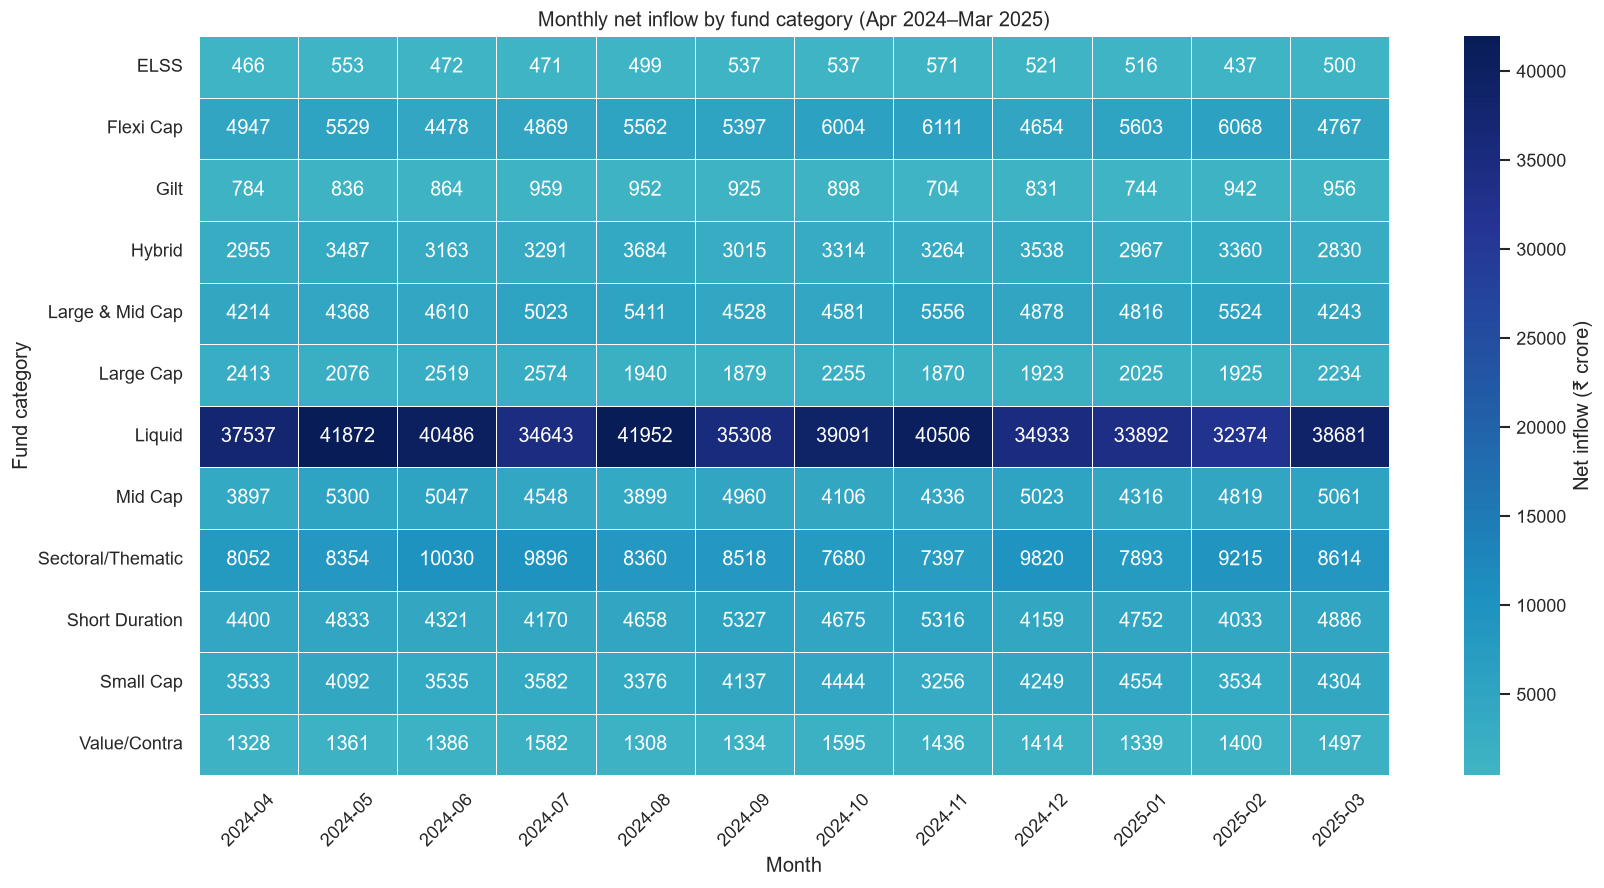

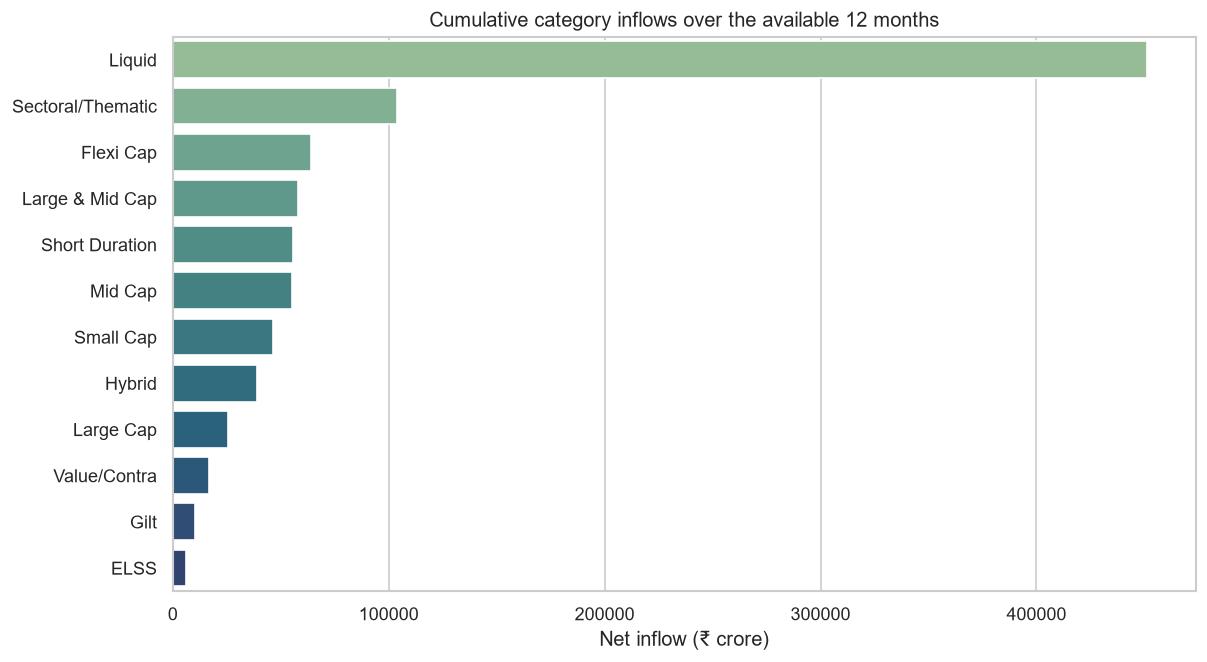

In [5]:
category_pivot=CATEGORY.pivot_table(index='category',columns=CATEGORY.month.dt.strftime('%Y-%m'),values='net_inflow_crore',aggfunc='sum')
fig,ax=plt.subplots(figsize=(16,8)); sns.heatmap(category_pivot,annot=True,fmt='.0f',cmap='YlGnBu',center=0,linewidths=.35,mask=category_pivot.isna(),cbar_kws={'label':'Net inflow (₹ crore)'},ax=ax)
ax.set(title='Monthly net inflow by fund category (Apr 2024–Mar 2025)',xlabel='Month',ylabel='Fund category'); ax.tick_params(axis='x',rotation=45)
finish_seaborn(save_seaborn(fig,'09_category_inflow_heatmap'));

category_totals=CATEGORY.groupby('category',as_index=False).net_inflow_crore.sum().sort_values('net_inflow_crore',ascending=False)
fig,ax=plt.subplots(figsize=(11,6)); sns.barplot(data=category_totals,x='net_inflow_crore',y='category',hue='category',palette='crest',legend=False,ax=ax)
ax.set(title='Cumulative category inflows over the available 12 months',xlabel='Net inflow (₹ crore)',ylabel=''); finish_seaborn(save_seaborn(fig,'10_category_inflow_totals'))

## 5. Investor demographics

Demographic charts use transaction-row counts and SIP transaction amounts from the supplied transaction sample; they describe this dataset, not the full investor population.

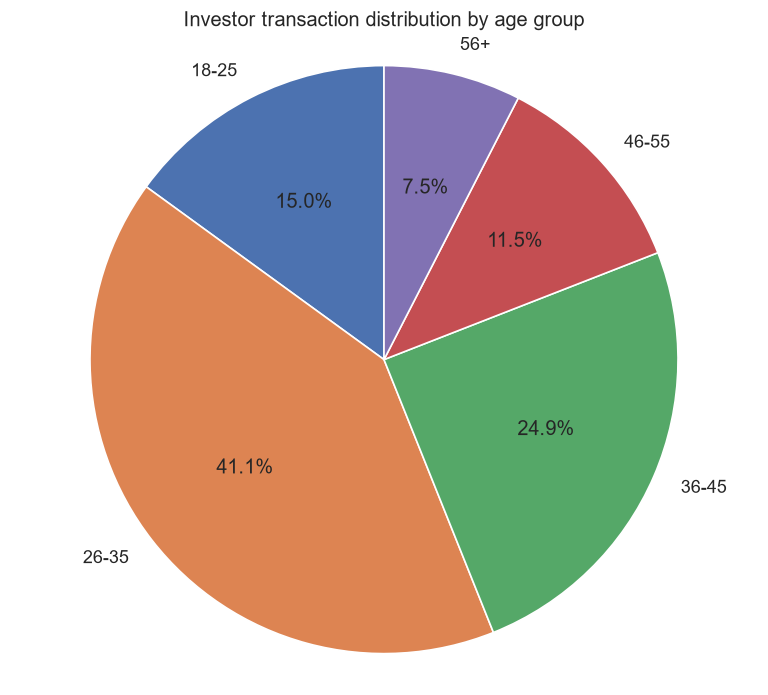

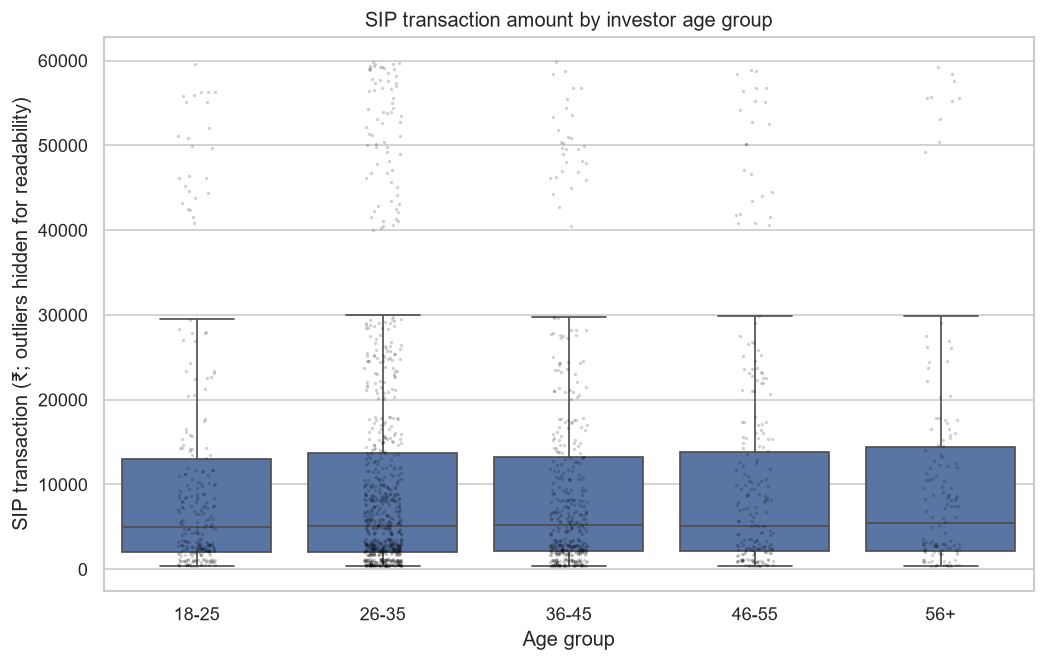

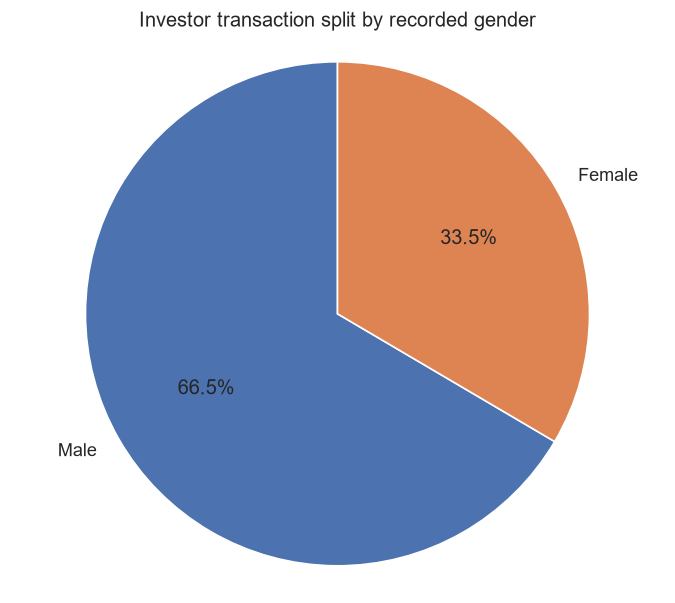

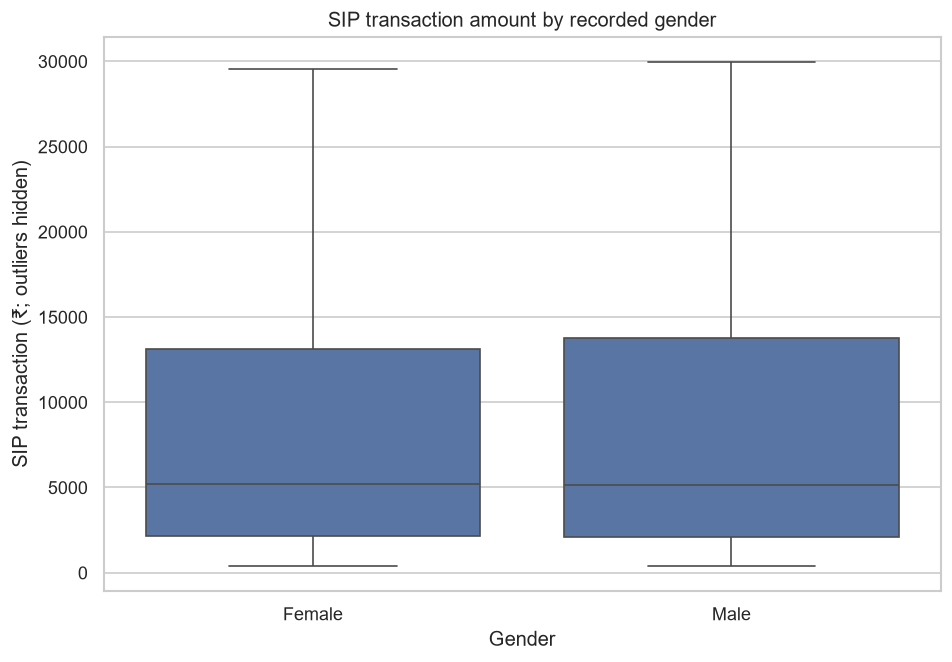

In [6]:
age_order=['18-25','26-35','36-45','46-55','56+']
age_counts=TRANSACTIONS.age_group.value_counts().reindex(age_order,fill_value=0)
fig,ax=plt.subplots(figsize=(8,7)); ax.pie(age_counts,labels=age_counts.index,autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor':'white'}); ax.set_title('Investor transaction distribution by age group'); ax.axis('equal')
finish_seaborn(save_seaborn(fig,'11_investor_age_distribution'));

sip_tx=TRANSACTIONS.loc[TRANSACTIONS.transaction_type.eq('SIP')].copy()
fig,ax=plt.subplots(figsize=(10,6)); sns.boxplot(data=sip_tx,x='age_group',y='amount_inr',order=age_order,showfliers=False,ax=ax); sns.stripplot(data=sip_tx.sample(min(1800,len(sip_tx)),random_state=42),x='age_group',y='amount_inr',order=age_order,color='black',alpha=.18,size=2,ax=ax)
ax.set(title='SIP transaction amount by investor age group',xlabel='Age group',ylabel='SIP transaction (₹; outliers hidden for readability)'); finish_seaborn(save_seaborn(fig,'12_sip_amount_by_age_boxplot'));

gender_counts=TRANSACTIONS.gender.value_counts()
fig,ax=plt.subplots(figsize=(7,6)); ax.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor':'white'}); ax.set_title('Investor transaction split by recorded gender'); ax.axis('equal')
finish_seaborn(save_seaborn(fig,'13_gender_split'));

fig,ax=plt.subplots(figsize=(9,6)); sns.boxplot(data=sip_tx,x='gender',y='amount_inr',showfliers=False,ax=ax); ax.set(title='SIP transaction amount by recorded gender',xlabel='Gender',ylabel='SIP transaction (₹; outliers hidden)'); finish_seaborn(save_seaborn(fig,'14_sip_amount_by_gender'))

## 6. Geographic distribution

State totals include SIP transactions only; city-tier distribution is shown both as transaction share and amount share to distinguish frequency from value.

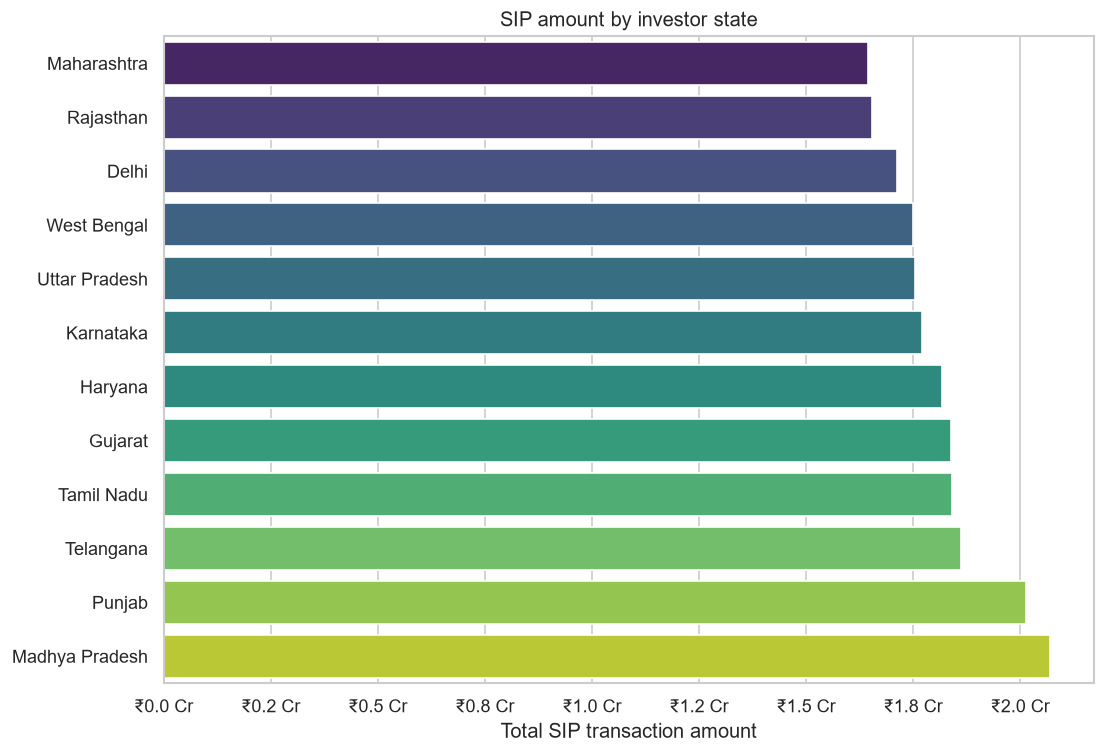

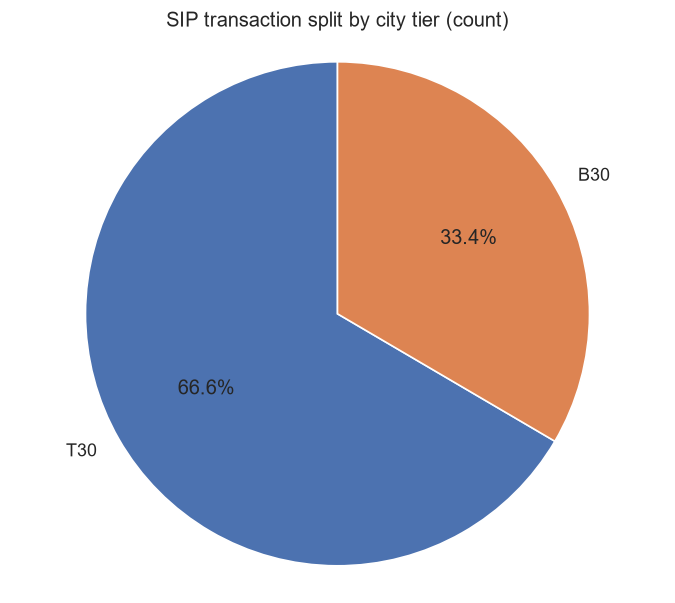

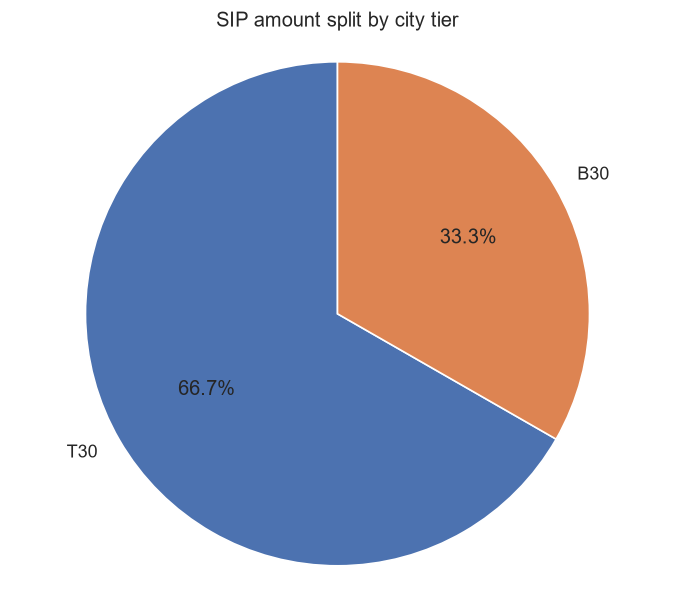

In [7]:
sip_state=sip_tx.groupby('state',as_index=False).amount_inr.sum().sort_values('amount_inr',ascending=True)
fig,ax=plt.subplots(figsize=(10,7)); sns.barplot(data=sip_state,x='amount_inr',y='state',hue='state',palette='viridis',legend=False,ax=ax); ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_:f'₹{x/1e7:.1f} Cr')); ax.set(title='SIP amount by investor state',xlabel='Total SIP transaction amount',ylabel=''); finish_seaborn(save_seaborn(fig,'15_sip_amount_by_state'));

tier_counts=sip_tx.city_tier.value_counts().reindex(['T30','B30'],fill_value=0)
fig,ax=plt.subplots(figsize=(7,6)); ax.pie(tier_counts,labels=tier_counts.index,autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor':'white'}); ax.set_title('SIP transaction split by city tier (count)'); ax.axis('equal'); finish_seaborn(save_seaborn(fig,'16_sip_city_tier_count'));

tier_amount=sip_tx.groupby('city_tier').amount_inr.sum().reindex(['T30','B30'],fill_value=0)
fig,ax=plt.subplots(figsize=(7,6)); ax.pie(tier_amount,labels=tier_amount.index,autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor':'white'}); ax.set_title('SIP amount split by city tier'); ax.axis('equal'); finish_seaborn(save_seaborn(fig,'17_sip_city_tier_amount'))

## 7. Folio-count growth

This series contains 21 reported observations between Jan 2022 and Dec 2025, not monthly values for every month. Milestones are annotated at source observations near 15, 20, and 25 crore.

In [8]:
fig=go.Figure(go.Scatter(x=FOLIO.month,y=FOLIO.total_folios_crore,mode='lines+markers',line=dict(width=3,color='#2a7f62'),name='Total folios'))
for threshold in (15,20,25):
    milestone=FOLIO.loc[(FOLIO.total_folios_crore-threshold).abs().idxmin()]
    fig.add_annotation(x=milestone.month,y=milestone.total_folios_crore,text=f"{milestone.total_folios_crore:.2f} Cr ({milestone.month:%b %Y})",showarrow=True,ax=0,ay=-35)
fig.update_layout(xaxis_title='Reporting month',yaxis_title='Total folios (crore)')
finish_plotly(save_plotly(fig,'18_industry_folio_growth','Industry folio growth — reported observations'))

## 8. NAV-return correlation

The first 10 schemes in the fund master are selected deterministically. Correlation uses daily percentage returns computed from the cleaned NAV calendar; forward-filled days yield zero returns on non-observation days and are therefore part of this correlation definition.

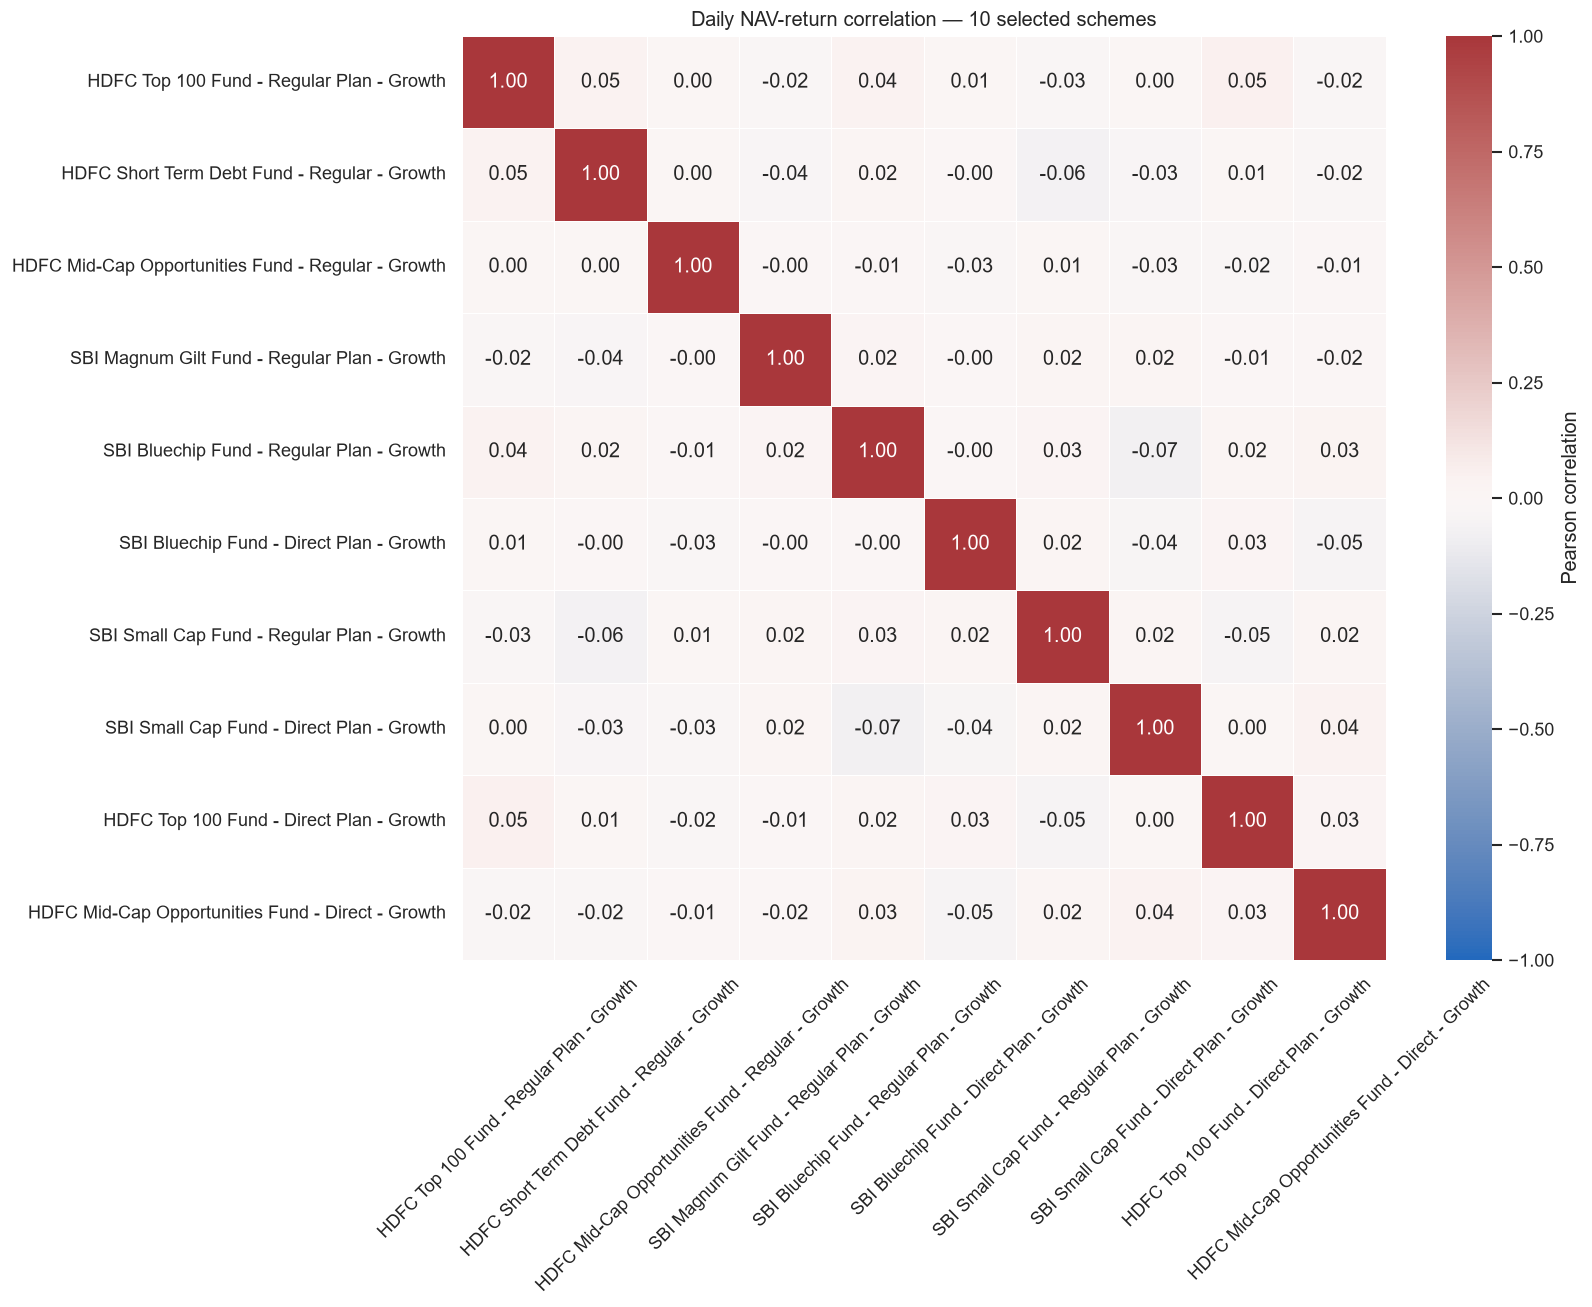

In [9]:
selected_codes=FUND.amfi_code.head(10).tolist()
selected_names=FUND.set_index('amfi_code').scheme_name
returns=(NAV.loc[NAV.amfi_code.isin(selected_codes)].pivot(index='date',columns='amfi_code',values='nav').sort_index().pct_change(fill_method=None))
returns.columns=[selected_names.loc[code] for code in returns.columns]
corr=returns.corr(min_periods=60)
fig,ax=plt.subplots(figsize=(13,10)); sns.heatmap(corr,annot=True,fmt='.2f',cmap='vlag',center=0,vmin=-1,vmax=1,square=True,linewidths=.4,cbar_kws={'label':'Pearson correlation'},ax=ax); ax.set_title('Daily NAV-return correlation — 10 selected schemes'); ax.tick_params(axis='x',rotation=45)
finish_seaborn(save_seaborn(fig,'19_nav_return_correlation_10_funds'));

fig,ax=plt.subplots(figsize=(10,7)); sns.clustermap(corr,cmap='vlag',center=0,vmin=-1,vmax=1,annot=True,fmt='.2f',figsize=(11,10),cbar_kws={'label':'Pearson correlation'}); plt.suptitle('Hierarchically clustered NAV-return correlations',y=1.02); CHARTS.append(('20_nav_return_correlation_clustered',CHART_DIR/'20_nav_return_correlation_clustered.png')); plt.savefig(CHART_DIR/'20_nav_return_correlation_clustered.png',dpi=180,bbox_inches='tight',facecolor='white'); plt.close('all')

## 9. Portfolio sector allocation

Aggregate sector allocation is computed as the arithmetic mean of fund-level sector weights after first summing each fund's holdings within sector. This gives each fund equal weight and avoids letting funds with more line items dominate; the data is a single 2025-12-31 snapshot.

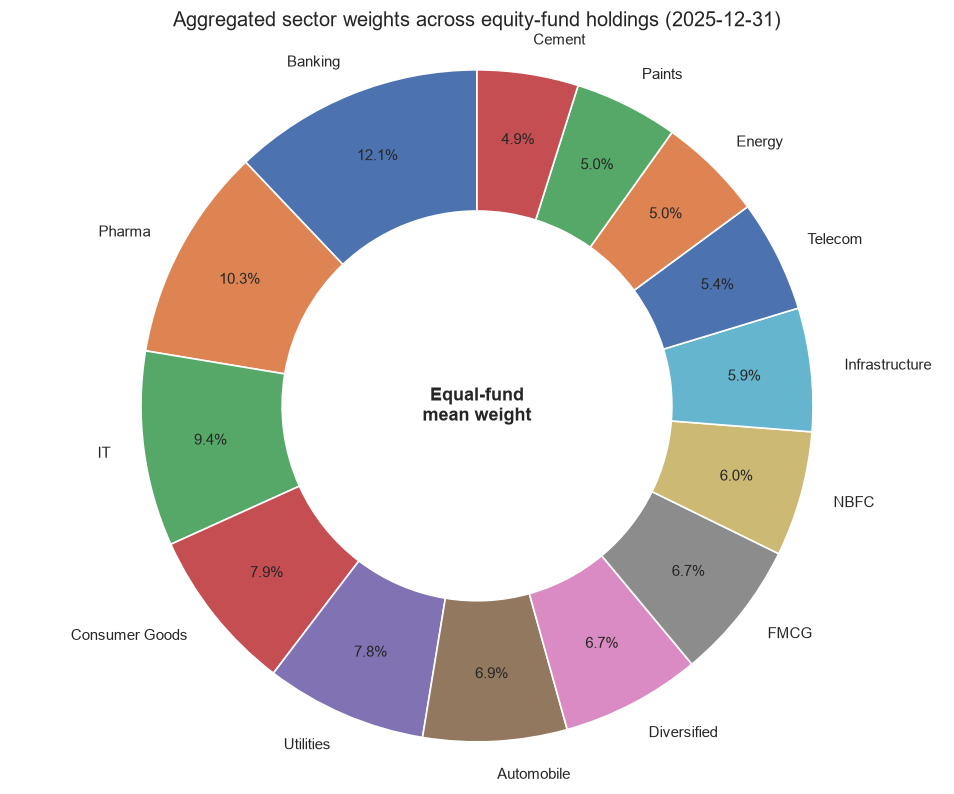

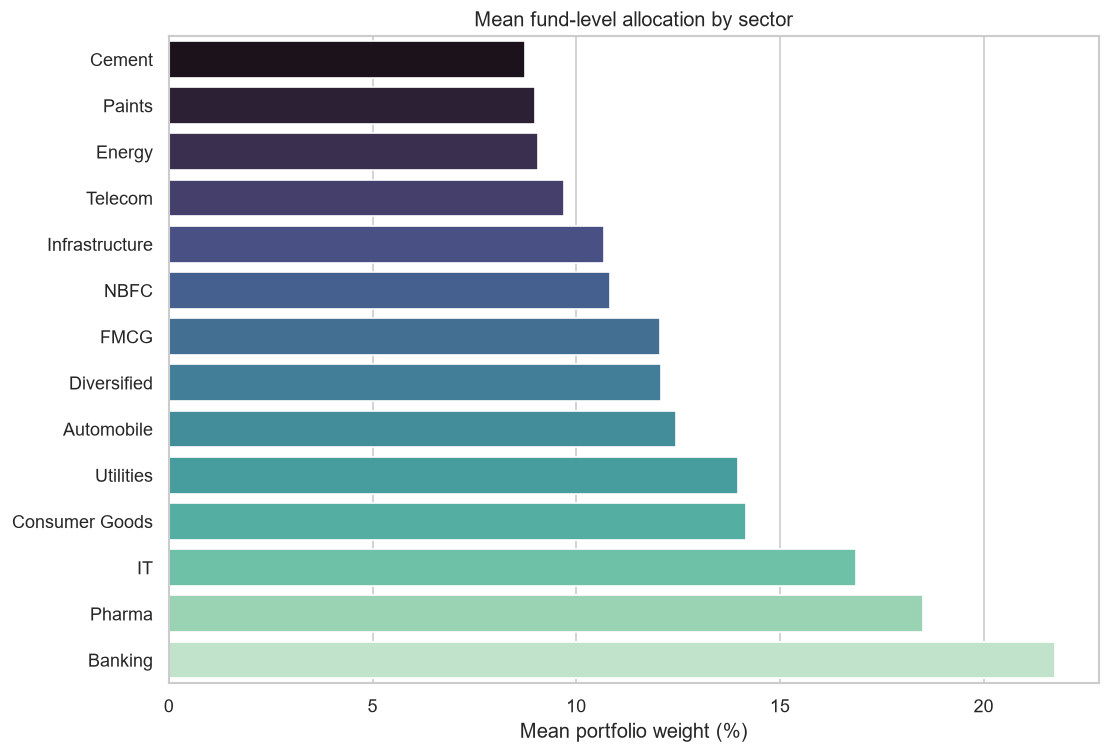

In [10]:
fund_sector=HOLDINGS.groupby(['amfi_code','sector'],as_index=False).weight_pct.sum()
sector_aggregate=fund_sector.groupby('sector',as_index=False).weight_pct.mean().sort_values('weight_pct',ascending=False)
fig,ax=plt.subplots(figsize=(10,8)); wedges,texts,autotexts=ax.pie(sector_aggregate.weight_pct,labels=sector_aggregate.sector,autopct='%1.1f%%',startangle=90,pctdistance=.8,wedgeprops={'width':.42,'edgecolor':'white'},textprops={'fontsize':9}); ax.text(0,0,'Equal-fund\nmean weight',ha='center',va='center',fontsize=11,fontweight='bold'); ax.set_title('Aggregated sector weights across equity-fund holdings (2025-12-31)'); ax.axis('equal'); finish_seaborn(save_seaborn(fig,'21_sector_allocation_donut'));

fig,ax=plt.subplots(figsize=(10,7)); sns.barplot(data=sector_aggregate.sort_values('weight_pct'),x='weight_pct',y='sector',hue='sector',palette='mako',legend=False,ax=ax); ax.set(title='Mean fund-level allocation by sector',xlabel='Mean portfolio weight (%)',ylabel=''); finish_seaborn(save_seaborn(fig,'22_sector_allocation_bar'))

## 10. Additional performance and transaction views

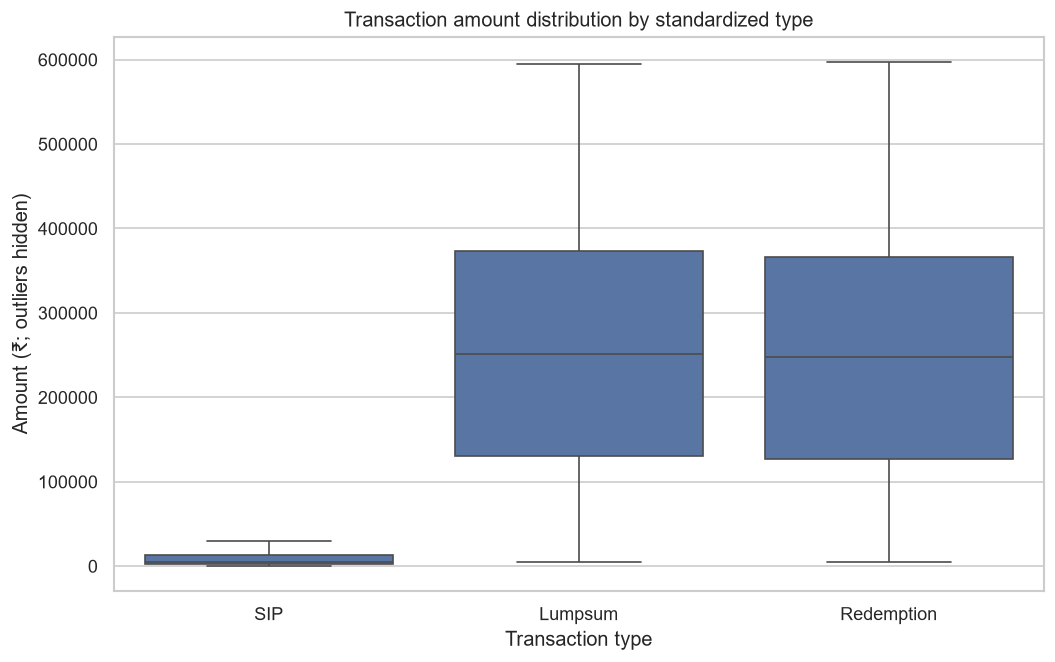

In [11]:
perf=PERFORMANCE.merge(FUND[['amfi_code','scheme_name','fund_house','category']].rename(columns={'scheme_name':'master_scheme_name','fund_house':'master_fund_house','category':'master_category'}),on='amfi_code')
fig=px.scatter(perf,x='return_3yr_pct',y='return_5yr_pct',color='master_category',size='aum_crore',hover_name='master_scheme_name',labels={'return_3yr_pct':'3-year return (%)','return_5yr_pct':'5-year return (%)','aum_crore':'AUM (₹ crore)','master_category':'Category'})
finish_plotly(save_plotly(fig,'23_performance_3yr_vs_5yr','Three-year vs five-year scheme returns'));

fig=px.scatter(perf,x='expense_ratio_pct',y='return_3yr_pct',color='plan',symbol='master_category',hover_name='master_scheme_name',labels={'expense_ratio_pct':'Expense ratio (%)','return_3yr_pct':'3-year return (%)','master_category':'Category'})
finish_plotly(save_plotly(fig,'24_expense_vs_return','Expense ratio vs three-year return'));

tx_mix=TRANSACTIONS.groupby(['transaction_type','gender'],as_index=False).amount_inr.sum()
fig=px.bar(tx_mix,x='transaction_type',y='amount_inr',color='gender',barmode='group',labels={'amount_inr':'Total amount (₹)','transaction_type':'Transaction type'})
finish_plotly(save_plotly(fig,'25_transaction_amount_type_gender','Transaction amount by transaction type and gender'));

fig,ax=plt.subplots(figsize=(10,6)); sns.boxplot(data=TRANSACTIONS,x='transaction_type',y='amount_inr',showfliers=False,order=['SIP','Lumpsum','Redemption'],ax=ax); ax.set(title='Transaction amount distribution by standardized type',xlabel='Transaction type',ylabel='Amount (₹; outliers hidden)'); finish_seaborn(save_seaborn(fig,'26_transaction_amount_boxplot'))

## Ten key EDA findings

Each finding is one evidence-based insight sentence followed by its supporting chart reference; run the prior cells to refresh the source-derived evidence.

1. NAV history covers 40 schemes from January 2022 through May 2026, with distinct raw NAV scales that make indexed growth a useful cross-fund comparison — charts `01_nav_daily_all_schemes.png` and `02_nav_indexed_40_schemes.png`.
2. The 2023 period and 2024 correction window can be compared across schemes, but the shaded intervals are descriptive windows rather than causal attribution — charts `01_nav_daily_all_schemes.png` and `02_nav_indexed_40_schemes.png`.
3. SBI Mutual Fund's latest 2025 AUM snapshot is ₹12.5 lakh crore, the largest fund-house observation in the supplied AUM data — charts `04_aum_grouped_by_fund_house.png` and `05_aum_latest_ranking.png`.
4. December 2025 SIP inflow is ₹31,002 crore and the maximum of the supplied 48-month SIP series — chart `06_sip_monthly_inflows.png`.
5. Category inflows are available for only April 2024 through March 2025, so the heatmap and category totals describe that 12-month window only — charts `09_category_inflow_heatmap.png` and `10_category_inflow_totals.png`.
6. Transaction rows are concentrated across five recorded age bands and two recorded gender values; this describes the provided transaction sample, not population-level investor demographics — charts `11_investor_age_distribution.png` and `13_gender_split.png`.
7. SIP ticket-size distributions differ by age band and recorded gender and are shown with extreme values hidden to make the central distributions legible — charts `12_sip_amount_by_age_boxplot.png` and `14_sip_amount_by_gender.png`.
8. State-level SIP amount totals and T30/B30 transaction/amount shares reveal different geographic views of the same investor transaction sample — charts `15_sip_amount_by_state.png`, `16_sip_city_tier_count.png`, and `17_sip_city_tier_amount.png`.
9. Reported industry folios grew from 13.26 crore in January 2022 to 26.12 crore in December 2025 across 21 snapshots — chart `18_industry_folio_growth.png`.
10. Pairwise daily NAV-return correlations among the deterministic first 10 schemes summarize co-movement in forward-filled daily data, including zero-return holidays/weekends — charts `19_nav_return_correlation_10_funds.png` and `20_nav_return_correlation_clustered.png`.

Additional performance, sector-allocation, and transaction charts are in `reports/charts/`; chart 21/22's sector statistic is the equal-fund mean, not an AUM-weighted market-wide estimate.

In [12]:
print(f"Figures registered: {len(CHARTS)}")
existing=[(name,path) for name,path in CHARTS if path.exists()]
missing=[(name,path) for name,path in CHARTS if not path.exists()]
print(f"PNG charts exported: {len(existing)} / {len(CHARTS)}")
if missing:
    print('Charts without PNG output (typically Plotly static-export backend missing):')
    for name,path in missing: print(f'  {name}: {path}')
else:
    print(f"All chart PNGs are available in {CHART_DIR}")
assert len(CHARTS) >= 15
assert len(existing) >= 15, 'At least 15 PNG charts must export for the report.'
print('Finding values:', {'SIP peak (₹ crore)': int(sip_peak.sip_inflow_crore), 'SBI latest AUM (₹ lakh crore)': round(float(sbi.iloc[0].aum_lakh_crore_actual),2) if not sbi.empty else None, 'folios first/last (crore)': (float(FOLIO.iloc[0].total_folios_crore),float(FOLIO.iloc[-1].total_folios_crore)), 'NAV schemes': int(NAV.amfi_code.nunique())})

Figures registered: 26
PNG charts exported: 26 / 26
All chart PNGs are available in c:\Users\nihar\OneDrive\Desktop\Mutual Funds Analysis\reports\charts
Finding values: {'SIP peak (₹ crore)': 31002, 'SBI latest AUM (₹ lakh crore)': 12.5, 'folios first/last (crore)': (13.26, 26.12), 'NAV schemes': 40}
